# XBeach Procedural Workflow

This notebook demonstrates the **procedural approach** to setting up an XBeach model
using rompy-xbeach. Each component is defined step-by-step in Python code.

## What is rompy-xbeach?

**rompy-xbeach** is a Python package for configuring and running XBeach nearshore
wave models. It provides:

- **Type-safe configuration** using Pydantic models
- **Data interfaces** for generating forcing from various sources (NetCDF, CSV, etc.)
- **Grid and bathymetry** tools with interpolation and extension capabilities
- **Integration with rompy** for model run management

## Workflow Overview

1. **Define the model grid** - spatial extent and resolution
2. **Prepare bathymetry** - interpolate source data onto the grid
3. **Set up forcing** - wave boundaries, wind, and tide
4. **Configure physics** - wave breaking, friction, etc.
5. **Generate workspace** - create XBeach input files

For the **declarative approach** using YAML configuration, see the companion notebook.

In [1]:
from pathlib import Path
from datetime import timedelta
import shutil
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from cartopy import crs as ccrs

import warnings
warnings.filterwarnings("ignore")

## Setup

In [2]:
# Data directory (using test data from rompy-xbeach)
DATA_DIR = Path("../../../rompy-xbeach/tests/data")

# Output directory
OUT_DIR = Path("example-procedural-output")
if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir()

---
# Step 1: Define Model Times

The `TimeRange` defines the simulation period. This controls:
- Start and end times for forcing data extraction
- Simulation duration (`tstop` in XBeach)

In [3]:
from rompy.core.time import TimeRange

times = TimeRange(
    start="2023-01-01T00:00",
    end="2023-01-01T12:00",
    interval="1h",
)
print(f"Simulation period: {times.start} to {times.end}")
print(f"Duration: {times.duration}")

Simulation period: 2023-01-01 00:00:00 to 2023-01-01 12:00:00
Duration: 12:00:00


---
# Step 2: Define Model Grid

The `RegularGrid` defines the computational domain in XBeach coordinates.
The grid is defined by:
- **Origin** (`ori`): Reference point in geographic coordinates
- **Rotation** (`alfa`): Grid rotation angle (degrees from North)
- **Resolution** (`dx`, `dy`): Cell sizes in meters
- **Extent** (`nx`, `ny`): Number of cells in x and y directions
- **CRS**: Projected coordinate system for the grid

Text(0.5, 1.0, 'Model Grid')

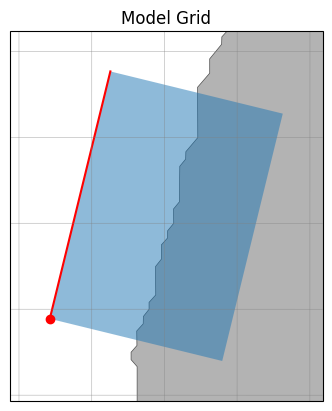

In [4]:
from rompy_xbeach.grid import RegularGrid

grid = RegularGrid(
    ori=dict(x=115.594239, y=-32.641104, crs="EPSG:4326"),
    alfa=347.0,       # Rotation angle (degrees from North)
    dx=10.0,          # Cross-shore resolution (m)
    dy=15.0,          # Alongshore resolution (m)
    nx=230,           # Number of cross-shore cells
    ny=220,           # Number of alongshore cells
    crs="EPSG:28350", # Projected CRS (MGA Zone 50)
)

# Visualize the grid
ax = grid.plot(scale="f")
ax.set_title("Model Grid")

---
# Step 3: Prepare Bathymetry

Bathymetry is prepared using `XBeachBathy` which handles:
- Loading source data (GeoTIFF, NetCDF, etc.)
- Interpolation onto the model grid
- Seaward extension to ensure uniform depth at the offshore boundary
- Lateral smoothing at the domain edges

## 3.1 Inspect Source Data

Text(0.5, 1.0, 'Source Bathymetry with Model Grid')

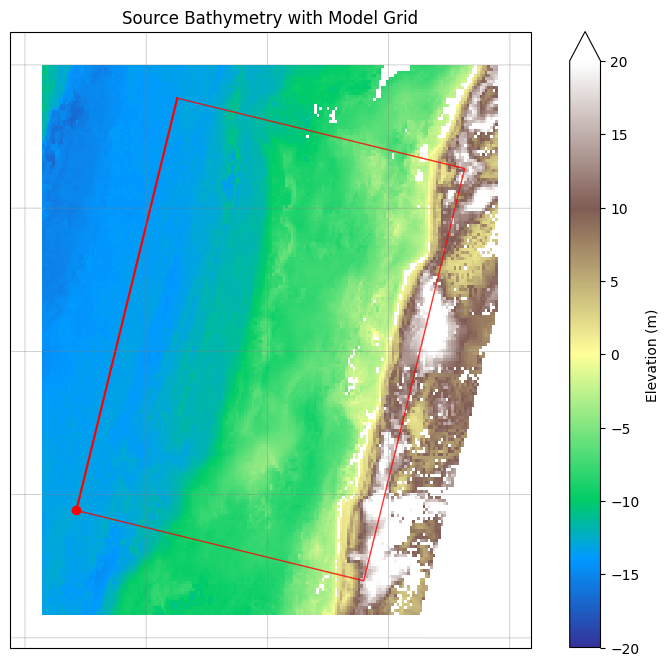

In [5]:
# Load and visualize the source bathymetry
bathyfile = DATA_DIR / "bathy.tif"
bathy_source = xr.open_dataset(bathyfile, engine="rasterio")

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=grid.projection))
bathy_source.band_data.isel(band=0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="terrain",
    vmin=-20, vmax=20,
    cbar_kwargs=dict(label="Elevation (m)"),
)
grid.plot(ax=ax, grid_kwargs=dict(facecolor="none", edgecolor="red", alpha=0.8))
ax.set_title("Source Bathymetry with Model Grid")

## 3.2 Configure Bathymetry Processing

In [6]:
from rompy_xbeach.source import SourceGeotiff
from rompy_xbeach.interpolate import RegularGridInterpolator
from rompy_xbeach.data.bathy import XBeachBathy, SeawardExtensionLinear

# Source data
source = SourceGeotiff(filename=bathyfile)

# Interpolation method
interpolator = RegularGridInterpolator(
    kwargs=dict(method="linear", fill_value=None)
)

# Seaward extension (extends grid offshore to reach target depth)
extension = SeawardExtensionLinear(
    depth=25.0,   # Target depth at offshore boundary (m)
    slope=0.1,    # Extension slope
)

# Create bathymetry object
bathy = XBeachBathy(
    source=source,
    posdwn=False,           # Depths are negative (elevation positive up)
    interpolator=interpolator,
    extension=extension,
    left=5,                 # Lateral smoothing cells (left edge)
    right=5,                # Lateral smoothing cells (right edge)
)

## 3.3 Generate and Visualize Bathymetry

Text(0.5, 1.0, 'Interpolated Model Bathymetry')

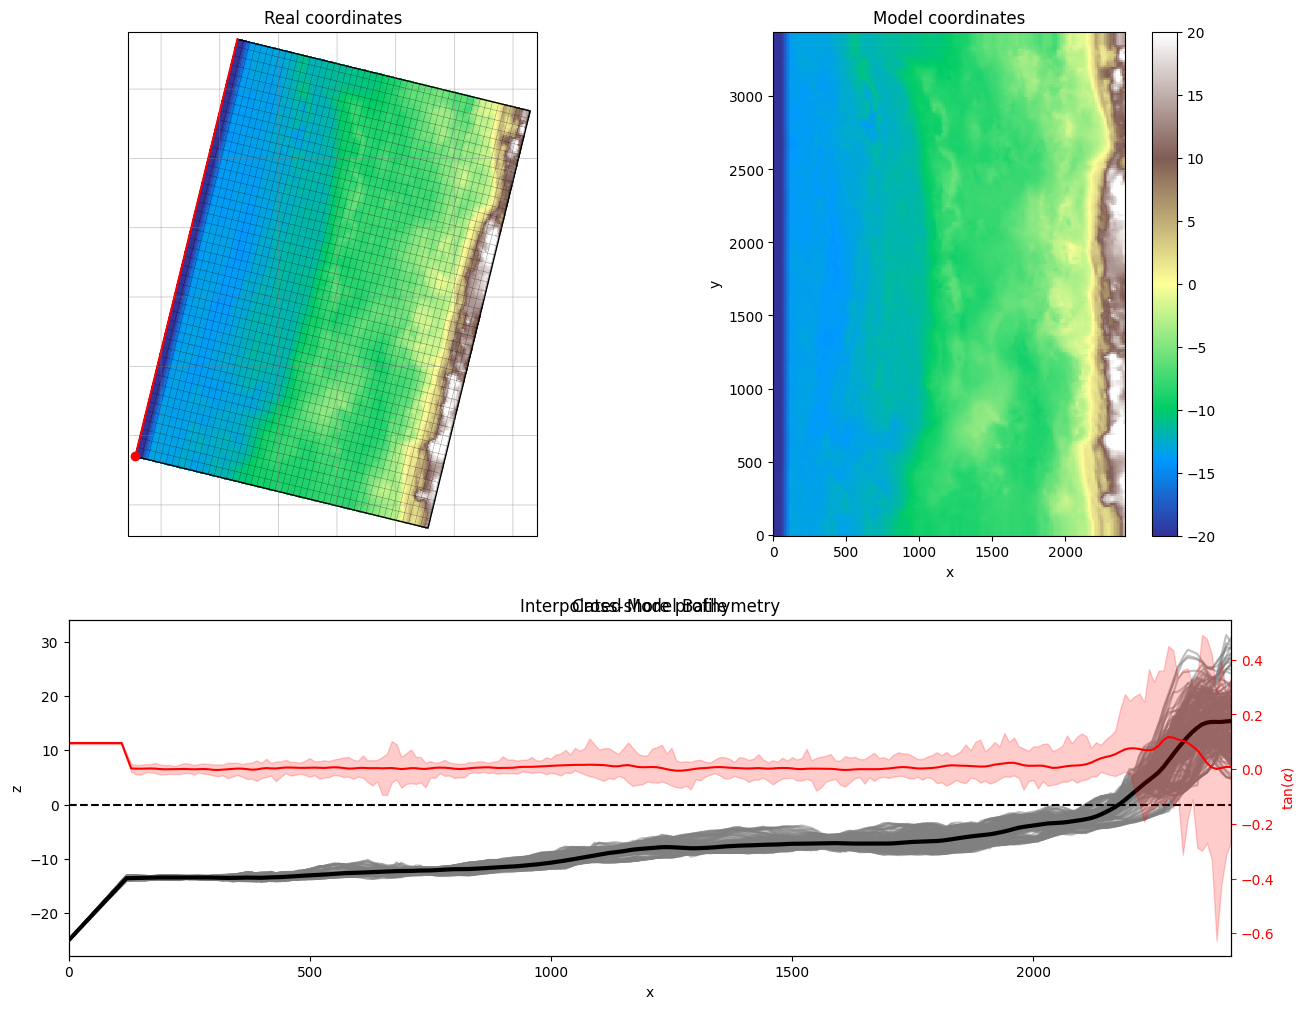

In [7]:
# Generate bathymetry files
destdir = OUT_DIR / "bathy_check"
destdir.mkdir(exist_ok=True)

xfile, yfile, depfile, grid_extended = bathy.get(destdir=destdir, grid=grid)

# Load and visualize
dset = xr.Dataset.xbeach.from_xbeach(depfile, grid_extended)
dset.xbeach.plot_model_bathy(grid_extended, posdwn=False)
plt.title("Interpolated Model Bathymetry")

---
# Step 4: Set Up Forcing

XBeach requires forcing for:
- **Wave boundary** - offshore wave conditions
- **Wind** - surface wind stress
- **Tide** - water level variations

## 4.1 Wave Boundary

Wave boundaries can be generated from spectral data or integrated parameters.
Here we use `BoundaryStationSpectraSwan` to create SWAN-format spectral files.

In [8]:
from rompy_xbeach.source import SourceCRSWavespectra
from rompy_xbeach.data.boundary import BoundaryStationSpectraSwan

# Define spectral data source
wave_source = SourceCRSWavespectra(
    uri=DATA_DIR / "ww3-spectra-20230101-short.nc",
    reader="read_ww3",
)

# Create wave boundary
wave = BoundaryStationSpectraSwan(source=wave_source)

### Visualize Wave Data

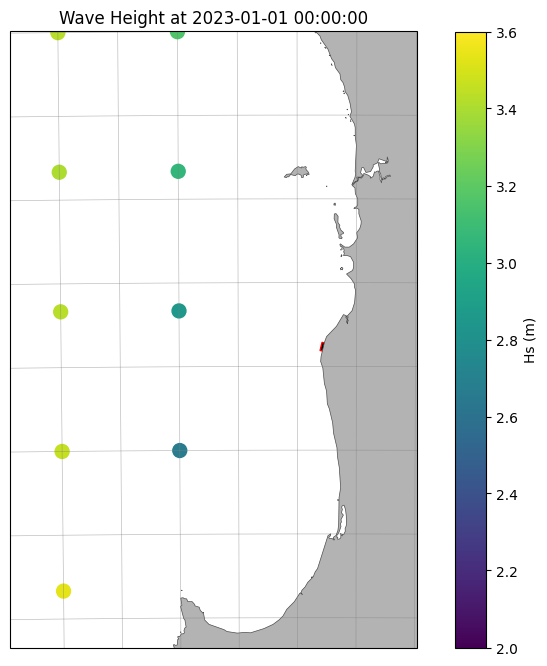

In [9]:
# Plot wave heights at first timestep
ds = wave_source.open().sel(time=times.start).squeeze()

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=grid.projection))
p = ax.scatter(
    ds.lon, ds.lat,
    s=100, c=ds.spec.hs(),
    cmap="viridis", vmin=2.0, vmax=3.6,
    transform=ccrs.PlateCarree(),
)
ax = grid.plot(
    ax=ax,
    scale="h",
    grid_kwargs=dict(facecolor="black", edgecolor="red", alpha=1.0),
    set_extent=False,
    set_gridlines=False,
    show_offshore=False,
    show_origin=False,
)
plt.colorbar(p, label="Hs (m)")
ax.set_title(f"Wave Height at {times.start}")
ax.set_extent([114.3, 116, -33.7, -31.5], crs=ccrs.PlateCarree())

## 4.2 Wind Forcing

Wind forcing is extracted from station or gridded data at the grid centre
or offshore boundary.

In [10]:
from rompy_xbeach.source import SourceCRSFile
from rompy_xbeach.data.wind import WindStation, WindVector

# Define wind data source
wind_source = SourceCRSFile(
    uri=DATA_DIR / "smc-params-20230101.nc",
    crs=4326,
)

# Create wind forcing (using vector components)
wind = WindStation(
    source=wind_source,
    coords=dict(s="seapoint"),
    wind_vars=WindVector(u="uwnd", v="vwnd"),
)

### Visualize Wind Data

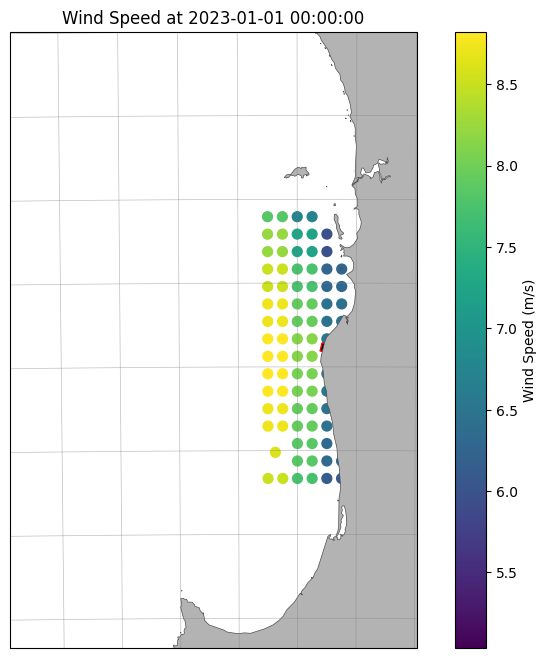

In [11]:
ds = wind_source.open().sel(time=times.start).squeeze()
wspd = (ds.uwnd**2 + ds.vwnd**2)**0.5

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection=grid.projection))
p = ax.scatter(
    ds.longitude,
    ds.latitude,
    s=50,
    c=wspd,
    cmap="viridis",
    transform=ccrs.PlateCarree(),
)
ax = grid.plot(
    ax=ax,
    scale="h",
    grid_kwargs=dict(facecolor="black", edgecolor="red", alpha=1.0),
    set_extent=False,
    set_gridlines=False,
    show_offshore=False,
    show_origin=False,
)
plt.colorbar(p, label="Wind Speed (m/s)")
ax.set_title(f"Wind Speed at {times.start}")
ax.set_extent([114.3, 116, -33.7, -31.5], crs=ccrs.PlateCarree())

## 4.3 Tide Forcing

Tide forcing is generated from tidal constituents using oceantide.

In [12]:
from rompy_xbeach.source import SourceCRSOceantide
from rompy_xbeach.data.waterlevel import TideConsGrid

# Define tidal constituent source
tide_source = SourceCRSOceantide(
    reader="read_otis_binary",
    kwargs=dict(
        gfile=DATA_DIR / "swaus_tide_cons/grid_m2s2n2k2k1o1p1q1mmmf",
        hfile=DATA_DIR / "swaus_tide_cons/h_m2s2n2k2k1o1p1q1mmmf",
        ufile=DATA_DIR / "swaus_tide_cons/u_m2s2n2k2k1o1p1q1mmmf",
    ),
    crs=4326,
)

# Create tide forcing
tide = TideConsGrid(
    source=tide_source,
    coords=dict(x="lon", y="lat"),
)

---
# Step 5: Configure the Model

The `Config` object brings together all components and defines XBeach parameters.
Parameters are organized into logical groups:
- **physics** - wave breaking, friction, numerics
- **flow_boundary** - boundary conditions
- **output** - output variables and timing

In [13]:
from rompy_xbeach.config import Config, DataInterface

config = Config(
    # Grid and bathymetry
    grid=grid,
    bathy=bathy,
    
    # Forcing data
    input=DataInterface(
        wave=wave,
        wind=wind,
        tide=tide,
    ),
    
    # Flow boundary conditions
    flow_boundary=dict(
        front="abs_2d",
        back="abs_2d",
        left="neumann",
        right="neumann",
    ),
    
    # Tide boundary
    tide_boundary=dict(
        zs0=0.0,
        paulrevere="land",
    ),
    
    # Output configuration
    output=dict(
        outputformat="netcdf",
        ncfilename="xboutput.nc",
        tstart=0,
        tintm=3600.0,
    ),
)

---
# Step 6: Generate Workspace

The `ModelRun` object generates the complete XBeach workspace with all input files.

In [14]:
from rompy.model import ModelRun

modelrun = ModelRun(
    run_id="procedural_example",
    period=times,
    output_dir=OUT_DIR,
    config=config,
)

# Generate the workspace
rundir = modelrun()

2026-03-09 09:39:28 [INFO] rompy.model         : ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
2026-03-09 09:39:28 [INFO] rompy.model         : ┃                      MODEL RUN CONFIGURATION                       ┃
2026-03-09 09:39:28 [INFO] rompy.model         : ┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
2026-03-09 09:39:28 [INFO] rompy.model         :             Run ID : procedural_example
2026-03-09 09:39:28 [INFO] rompy.model         :         Model Type : Config
2026-03-09 09:39:28 [INFO] rompy.model         :         Start Time : 2023-01-01T00:00:00
2026-03-09 09:39:28 [INFO] rompy.model         :           End Time : 2023-01-01T12:00:00
2026-03-09 09:39:28 [INFO] rompy.model         :           Duration : 12 hours
2026-03-09 09:39:28 [INFO] rompy.model         :      Time Interval : 1:00:00
2026-03-09 09:39:28 [INFO] rompy.model         :   Output Directory : example-procedural-output
2026-03-09 09:39:28 [INFO] rompy.model   

---
# Step 7: Inspect Generated Files

In [15]:
# List generated files
modeldir = Path(modelrun.output_dir) / modelrun.run_id
print("Generated files:")
for f in sorted(modeldir.glob("*")):
    print(f"  {f.name}")

Generated files:
  bathy.txt
  params.txt
  swan-20230101T000000.txt
  tide-20230101T000000-20230101T120000.txt
  wind-20230101T000000-20230101T120000.txt
  xdata.txt
  ydata.txt


In [16]:
# View params.txt
params_file = modeldir / "params.txt"
print(params_file.read_text()[:2000])  # First 2000 chars

%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%% XBeach parameter settings input file
%%%
%%% Date: 2026-03-08 20:39:28.786451+00:00
%%% User: rguedes-XPS-13-9350
%%% Template: /source/csiro/rompy-xbeach/src/rompy_xbeach/templates/base
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

tstop = 43200.0
tunits = seconds since 2023-01-01 00:00:00
wbctype = swan
bcfile = swan-20230101T000000.txt
windfile = wind-20230101T000000-20230101T120000.txt
zs0file = tide-20230101T000000-20230101T120000.txt
tideloc = 1
tidelen = 13
front = abs_2d
back = abs_2d
left = neumann
right = neumann
zs0 = 0.0
paulrevere = land
posdwn = -1
nx = 241
ny = 229
dx = 10.0
dy = 15.0
xori = 368011.2066131959
yori = 6387580.505638544
alfa = 347.0
projection = +proj=utm +zone=50 +south +ellps=GRS80 +units=m +no_defs +type=crs
depfile = bathy.txt
outputformat = netcdf
ncfilename = xboutput.nc
tstart = 0.0
tintm = 3600.0



## Inspect Forcing Files

In [17]:
def read_forcing(filepath, cols):
    """Read XBeach forcing file."""
    df = pd.read_csv(filepath, header=None, sep=r"\s+", names=cols)
    if "tsec" in cols:
        df["time"] = [times.start + timedelta(seconds=s) for s in df.tsec]
        df.set_index("time", inplace=True)
    return df

### Wind File

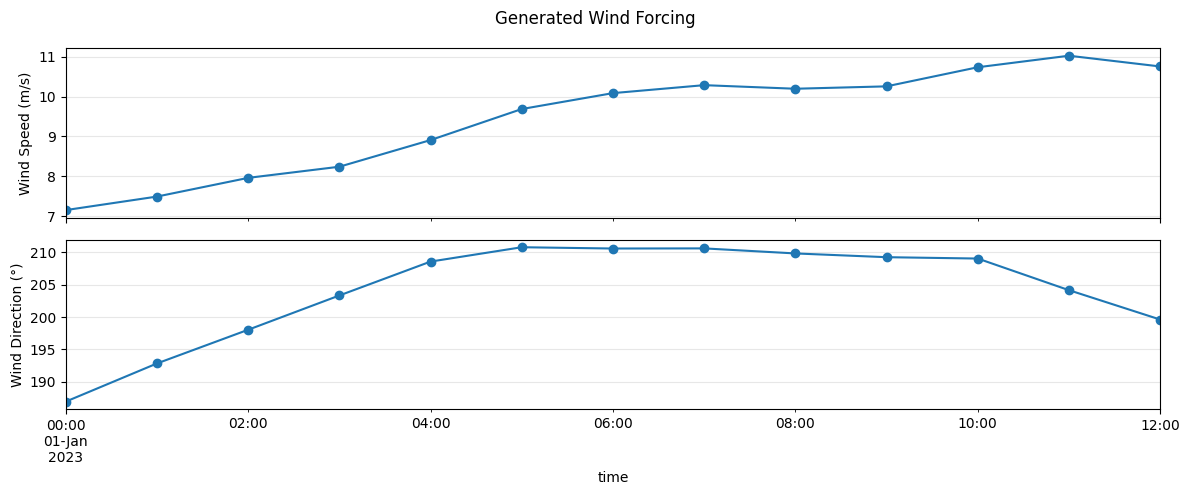

In [18]:
windfile = modeldir / config.params.get("windfile")
if windfile.exists():
    df_wind = read_forcing(windfile, ["tsec", "wspd", "wdir"])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    df_wind.wspd.plot(ax=ax1, marker="o")
    ax1.set_ylabel("Wind Speed (m/s)")
    ax1.grid(True, alpha=0.3)
    
    df_wind.wdir.plot(ax=ax2, marker="o")
    ax2.set_ylabel("Wind Direction (°)")
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle("Generated Wind Forcing")
    plt.tight_layout()

### Tide File

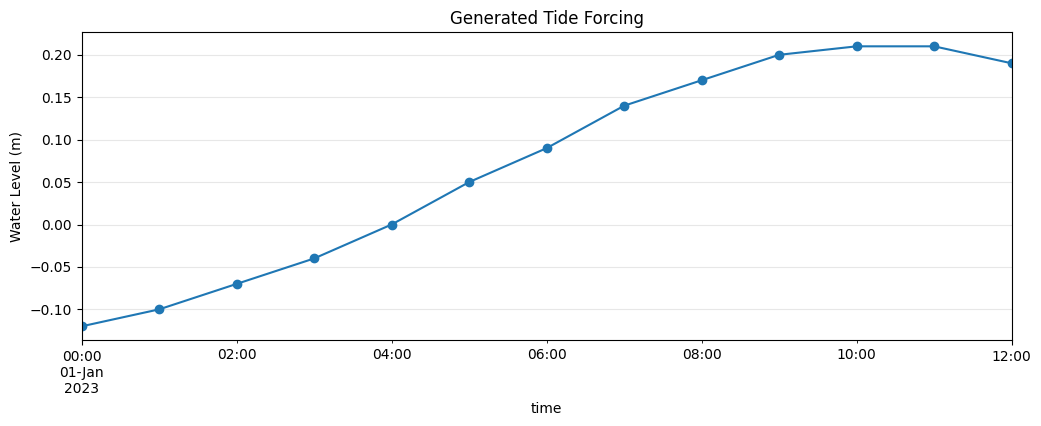

In [19]:
tidefile = modeldir / config.params.get("zs0file")
if tidefile.exists():
    df_tide = read_forcing(tidefile, ["tsec", "zs"])
    
    fig, ax = plt.subplots(figsize=(12, 4))
    df_tide.zs.plot(ax=ax, marker="o")
    ax.set_ylabel("Water Level (m)")
    ax.set_title("Generated Tide Forcing")
    ax.grid(True, alpha=0.3)

### Wave Boundary File

In [20]:
bcfile = modeldir / config.params.get("bcfile")
if bcfile.exists():
    print(f"Wave boundary file: {bcfile.name}")
    print(bcfile.read_text()[:500])

Wave boundary file: swan-20230101T000000.txt
SWAN   1                                Swan standard spectral file
$   Created by wavespectra
$   
LONLAT                                  locations in spherical coordinates
     1                                  number of locations
  115.598402  -32.626715
AFREQ                                   absolute frequencies in Hz
    31                                  number of frequencies
    0.03700
    0.04070
    0.04477
    0.04925
    0.05417
    0.05959
    0.06555
    0.07210
    0.07931
   


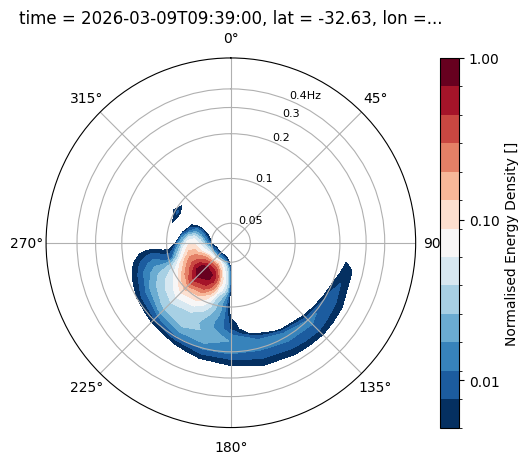

In [21]:
from wavespectra import read_swan

ds = read_swan(bcfile)
p = ds.squeeze().spec.plot()

---
# Summary

This notebook demonstrated the **procedural workflow** for setting up an XBeach model:

1. **TimeRange** - Define simulation period
2. **RegularGrid** - Define computational domain
3. **XBeachBathy** - Prepare bathymetry with interpolation and extension
4. **Data interfaces** - Set up wave, wind, and tide forcing
5. **Config** - Combine all components with physics parameters
6. **ModelRun** - Generate the complete XBeach workspace

## Next Steps

- See **Example Declarative** for YAML-based configuration
- See component tutorials in `components/` for detailed parameter options
- See data interface tutorials in `data-interface/` for forcing options

## Running XBeach

To run the model, execute XBeach in the generated workspace:
```bash
cd example-procedural-output/procedural_example
xbeach params.txt
```